In [1]:
import numpy as np
import matplotlib.pyplot as plt
import time
import os
import matplotlib.gridspec as gridspec

In [5]:
n_range = range(0, 10000, 10)

#complexities

full_kta = [n**2 for n in n_range]
random_kta = [(int(n/8))**2 for n in n_range]
quack_kta = [n for n in n_range]
greedy_kta = [(n * 10) + (int(n/8)**2) for n in n_range]
cc_kta = [(2 * int(n/8)) for n in n_range]

In [6]:
len(full_kta), len(random_kta), len(quack_kta), len(greedy_kta), len(cc_kta)

(1000, 1000, 1000, 1000, 1000)

In [12]:
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np

# ── global matplotlib style (publication-ready) ───────────────────────────
mpl.rcParams.update({
    'font.family':           'serif',
    'font.serif':            ['Times New Roman', 'DejaVu Serif'],
    'mathtext.fontset':      'stix',
    'axes.labelsize':        10,
    'axes.titlesize':        10,
    'xtick.labelsize':       9,
    'ytick.labelsize':       9,
    'legend.fontsize':       8,
    'legend.title_fontsize': 8,
    'figure.dpi':            300,
    'savefig.dpi':           300,
    'axes.linewidth':        0.8,
    'xtick.major.width':     0.8,
    'ytick.major.width':     0.8,
    'xtick.minor.width':     0.5,
    'ytick.minor.width':     0.5,
    'lines.linewidth':       1.6,
    'patch.linewidth':       0.6,
})

# ── publication color palette (colorblind-safe, Paul Tol) ─────────────────
METHOD_STYLES = {
    'fullKTA': {
        'color':     '#0077BB',   # blue
        'marker':    'o',
        'linestyle': '-',
    },
    'randomKTA': {
        'color':     '#009988',   # teal
        'marker':    's',
        'linestyle': '--',
    },
    'quackKTA': {
        'color':     '#EE7733',   # orange
        'marker':    '^',
        'linestyle': '-.',
    },
    'greedyKTA': {
        'color':     '#CC3311',   # vermillion
        'marker':    'D',
        'linestyle': ':',
    },
    'ccka': {
        'color':     '#AA3377',   # purple
        'marker':    'v',
        'linestyle': (0, (3, 1, 1, 1)),   # densely dash-dotted
    },
}

METHOD_LABELS = {
    'fullKTA':   'Full KTA — $O(n^2)$',
    'randomKTA': 'Random Sampling KTA — $O(k^2),\\ k=n/8$',
    'quackKTA':  'Quack KTA — $O(n)$',
    'greedyKTA': 'Greedy KTA — $O(nm)+O(g^2),\\ m=n/2$',
    'ccka':      'CCKA — $O(Ck),\\ C=10,\\ k=n/8$',
}


def plot_complexity_lines(
    x_values,
    arrays: dict,
    title:       str   = 'Circuit Executions Across KTA Methods by Training Samples',
    xlabel:      str   = 'Training Samples',
    ylabel:      str   = 'Circuit Executions',
    log_x:       bool  = True,
    log_y:       bool  = True,
    figsize:     tuple = (7, 4.5),
    save_prefix: str   = 'complexity_lines',
):
    """
    Plot multiple 1-D arrays on a single line chart.

    Parameters
    ----------
    x_values : array-like
        Shared x-axis values (length N).
    arrays : dict[str, array-like]
        Keys must match METHOD_STYLES / METHOD_LABELS.
        Each value is a length-N array of y values.
    title : str
        Figure title.
    xlabel / ylabel : str
        Axis labels.
    log_x / log_y : bool
        Use logarithmic scale on x / y axis.
    figsize : tuple
        Figure size in inches (width, height).
    save_prefix : str
        Files saved as  <save_prefix>.png  and  <save_prefix>.pdf
    """
    fig, ax = plt.subplots(figsize=figsize, facecolor='white')

    for method, y in arrays.items():
        sty   = METHOD_STYLES[method]
        label = METHOD_LABELS.get(method, method)
        ax.plot(
            x_values, y,
            label        = label,
            color        = sty['color'],
            markersize   = 5,
            linewidth    = 1.6,
            alpha        = 0.9,
            markerfacecolor  = 'white',
            markeredgewidth  = 1.4,
        )

    # ── axes ──────────────────────────────────────────────────────────────
    if log_x:
        ax.set_xscale('log')
    if log_y:
        ax.set_yscale('log')

    ax.set_xlabel(xlabel, fontsize=11)
    ax.set_ylabel(ylabel, fontsize=11)
    ax.set_title(title,   fontsize=11, fontweight='bold', pad=8)

    ax.grid(linestyle=':', linewidth=0.6, alpha=0.6, which='both')
    ax.spines[['top', 'right']].set_visible(False)
    ax.yaxis.set_minor_locator(mpl.ticker.LogLocator(subs='all', numticks=10))
    ax.xaxis.set_minor_locator(mpl.ticker.LogLocator(subs='all', numticks=10))
    ax.tick_params(which='minor', length=2)

    # ── legend ────────────────────────────────────────────────────────────
    ax.legend(
        fontsize     = 8,
        loc          = 'upper left',
        framealpha   = 0.88,
        edgecolor    = '#cccccc',
        frameon      = True,
        title        = 'Method',
        title_fontsize = 8,
    )

    fig.tight_layout()

    # ── save ──────────────────────────────────────────────────────────────
    for fmt in ('png', 'pdf'):
        fig.savefig(f'{save_prefix}.{fmt}',
                    dpi=600, bbox_inches='tight', facecolor='white')
    plt.show()
    print(f"Saved: {save_prefix}.png  /  {save_prefix}.pdf")

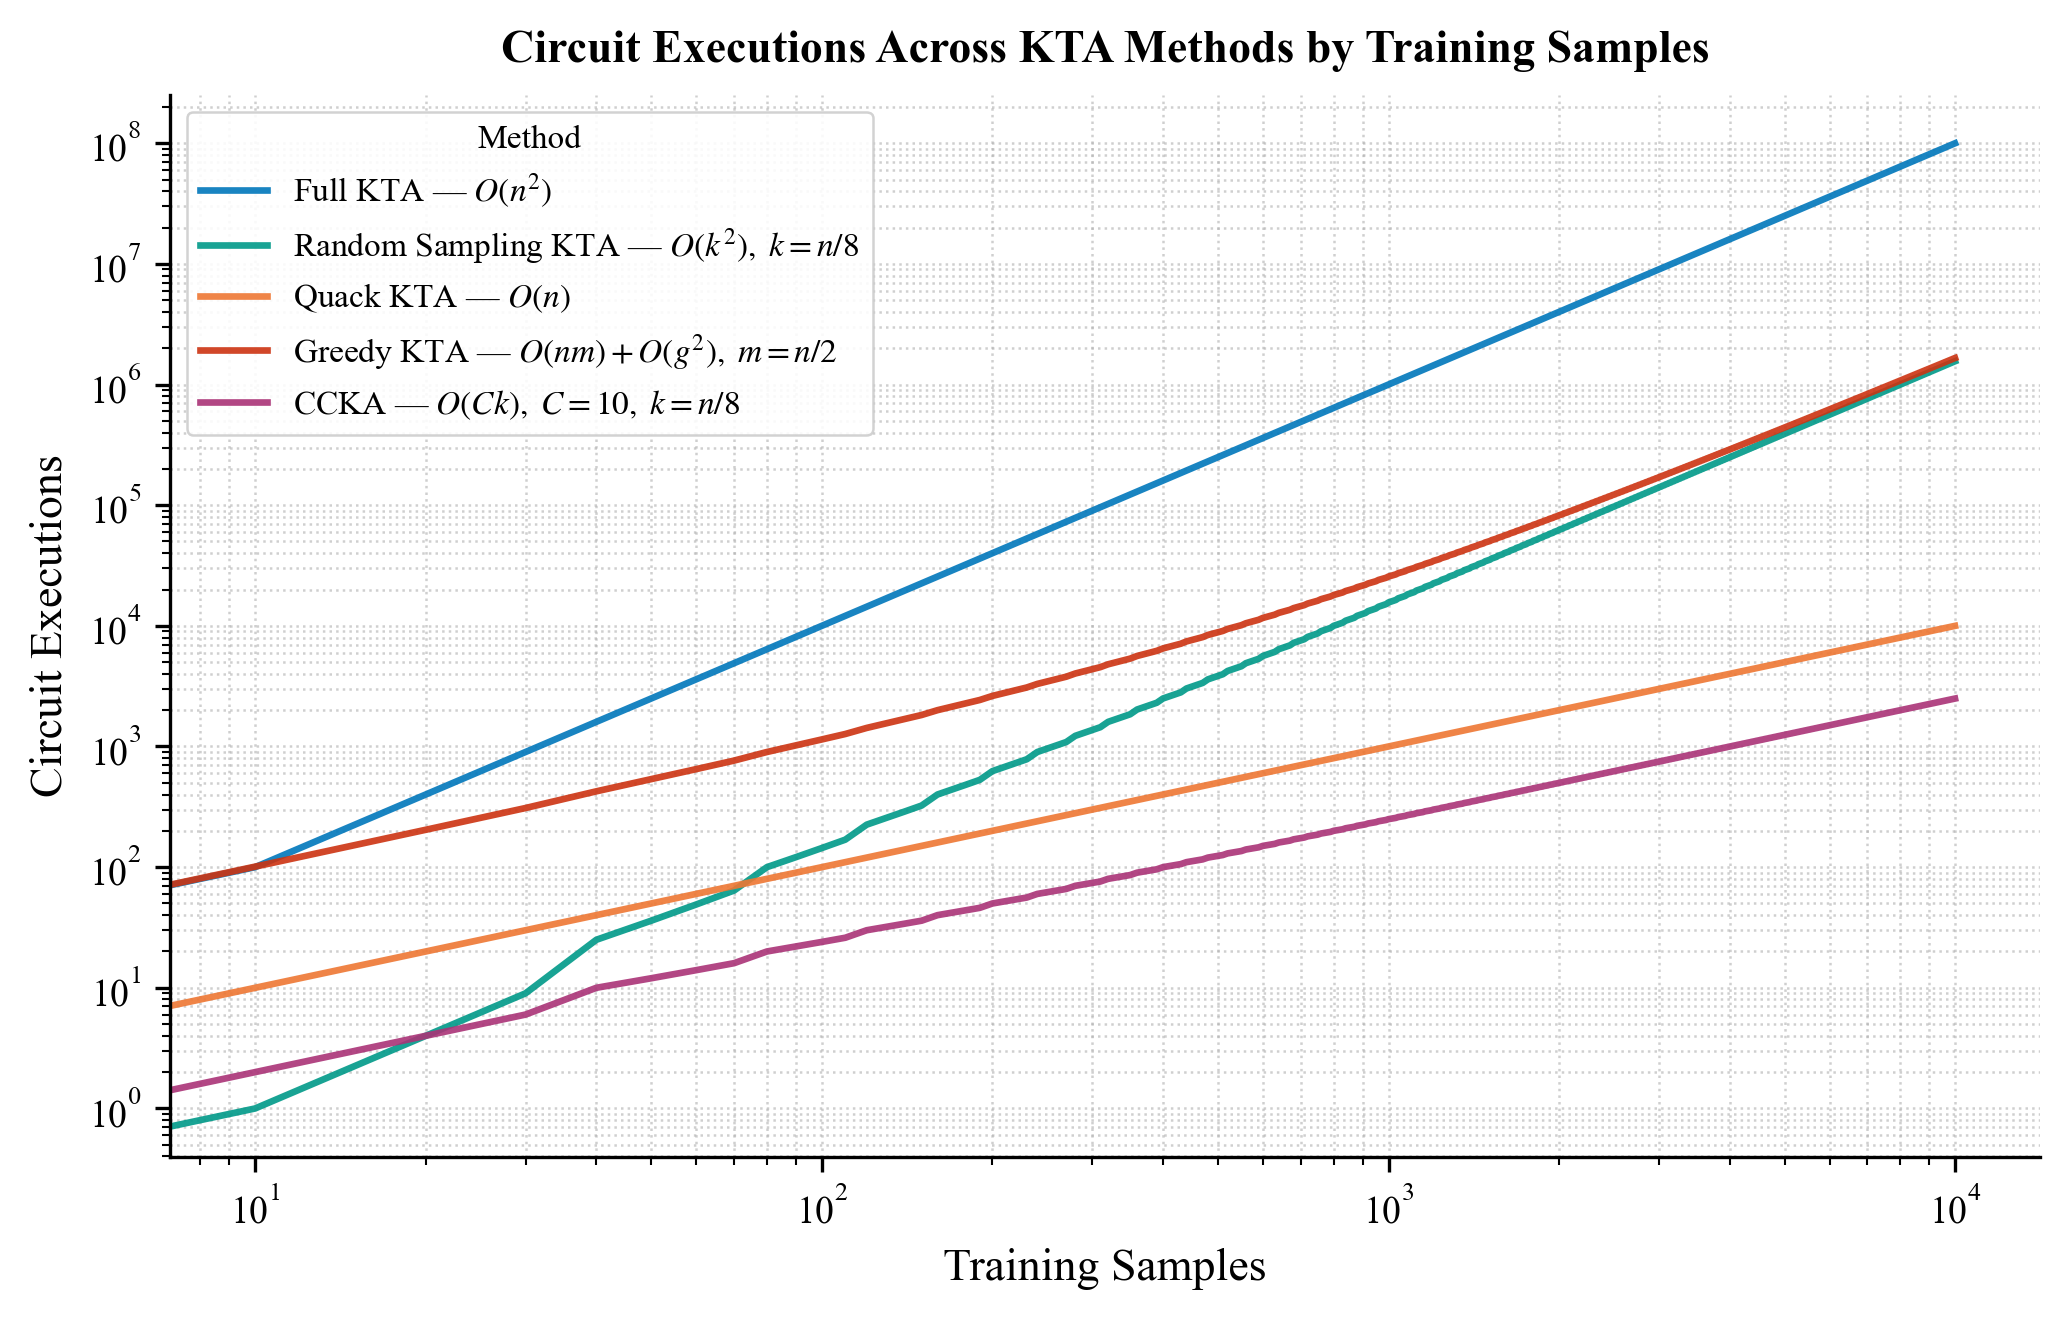

Saved: kta_complexity.png  /  kta_complexity.pdf


In [13]:
# ── example usage ─────────────────────────────────────────────────────────
if __name__ == '__main__':
    ns  = n_range
    C   = 2   # number of classes (CCKA)

    arrays = {
        'fullKTA':   full_kta,
        'randomKTA': random_kta,
        'quackKTA':  quack_kta,
        'greedyKTA': greedy_kta,
        'ccka':      cc_kta,
    }

    plot_complexity_lines(
        x_values     = ns,
        arrays       = arrays,
        log_x        = True,
        log_y        = True,
        save_prefix  = 'kta_complexity',
    )